In [1]:
import pandas as pd 

In [2]:
pop38 = pd.read_csv("data/popfordeling_2023-2038_tfr1_5.csv")
pop53 = pd.read_csv("data/popfordeling_2038-2078_tfr2_1.csv")

In [90]:
pop53.columns[3:]

Index(['pop_2039', 'pop_2040', 'pop_2041', 'pop_2042', 'pop_2043', 'pop_2044',
       'pop_2045', 'pop_2046', 'pop_2047', 'pop_2048', 'pop_2049', 'pop_2050',
       'pop_2051', 'pop_2052', 'pop_2053', 'pop_2054', 'pop_2055', 'pop_2056',
       'pop_2057', 'pop_2058', 'pop_2059', 'pop_2060', 'pop_2061', 'pop_2062',
       'pop_2063', 'pop_2064', 'pop_2065', 'pop_2066', 'pop_2067', 'pop_2068',
       'pop_2069', 'pop_2070', 'pop_2071', 'pop_2072', 'pop_2073', 'pop_2074',
       'pop_2075', 'pop_2076', 'pop_2077', 'pop_2078'],
      dtype='str')

In [91]:
pop53[pop53.columns[3:]]

,pop_2039,pop_2040,pop_2041,pop_2042,pop_2043,pop_2044,pop_2045,pop_2046,pop_2047,pop_2048,...,pop_2069,pop_2070,pop_2071,pop_2072,pop_2073,pop_2074,pop_2075,pop_2076,pop_2077,pop_2078
0,23620.0,25231.0,27213.0,28636.0,30162.0,31779.0,31347.0,31329.0,30593.0,30293.0,...,26530.0,26894.0,27151.0,27605.0,28510.0,28743.0,29133.0,29475.0,29538.0,30020.0
1,23782.0,23618.0,25227.0,27209.0,28632.0,30156.0,31775.0,31345.0,31324.0,30590.0,...,25881.0,26529.0,26893.0,27149.0,27605.0,28510.0,28742.0,29133.0,29474.0,29538.0
2,23818.0,23780.0,23613.0,25218.0,27206.0,28625.0,30153.0,31775.0,31341.0,31320.0,...,25872.0,25881.0,26528.0,26892.0,27148.0,27605.0,28509.0,28742.0,29133.0,29474.0
3,23744.0,23817.0,23776.0,23610.0,25212.0,27204.0,28625.0,30150.0,31771.0,31337.0,...,25539.0,25872.0,25880.0,26528.0,26892.0,27145.0,27602.0,28507.0,28741.0,29132.0
4,23925.0,23741.0,23811.0,23773.0,23609.0,25208.0,27203.0,28619.0,30144.0,31769.0,...,25465.0,25538.0,25872.0,25879.0,26527.0,26891.0,27145.0,27600.0,28506.0,28740.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,5.0,5.0,5.0,7.0,6.0,6.0,4.0,6.0,9.0
216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,2.0,2.0,1.0,1.0,2.0,3.0,NaN,2.0
217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
pop = pd.concat([pop38, pop53[pop53.columns[3:]]], axis=1)

In [93]:
pop.sum()

sex         KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK...
alder                                                   11990
pop_2023                                            5488984.0
pop_2024                                            5499060.0
pop_2025                                            5508499.0
pop_2026                                            5517326.0
pop_2027                                            5525459.0
pop_2028                                            5532909.0
pop_2029                                            5539706.0
pop_2030                                            5546061.0
pop_2031                                            5551757.0
pop_2032                                            5556903.0
pop_2033                                            5561346.0
pop_2034                                            5565442.0
pop_2035                                            5569102.0
pop_2036                                            5572445.0
pop_2037

In [96]:
pop.groupby("alder")[["pop_2023", "pop_2058"]].sum()

,pop_2023,pop_2058
alder,,
0,51991.0,53078.0
1,57415.0,53667.0
2,54778.0,54232.0
3,56455.0,54661.0
4,57146.0,55447.0
...,...,...
105,104.0,3.0
106,0.0,2.0
107,0.0,0.0


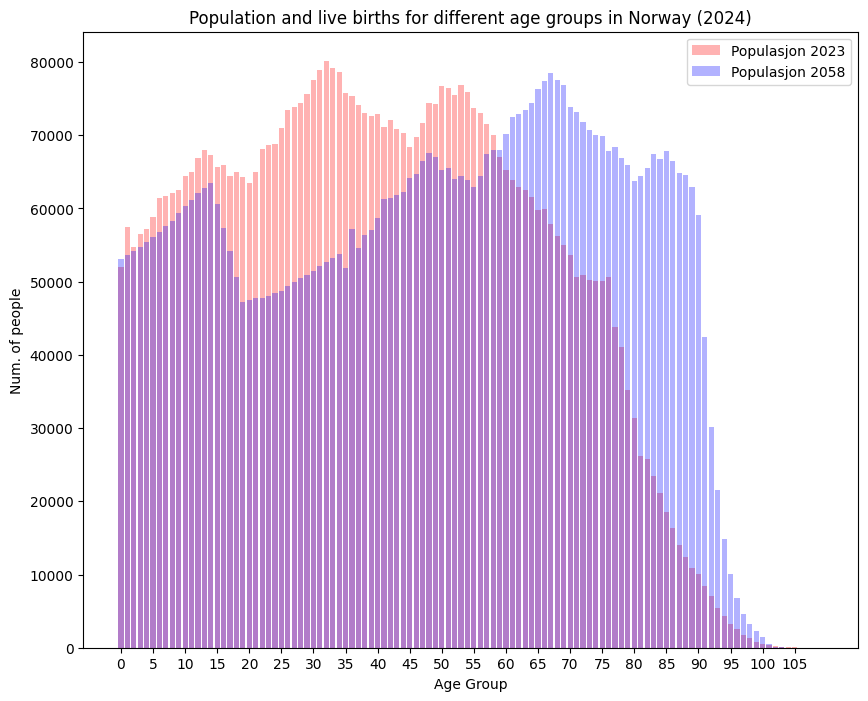

In [97]:

import matplotlib.pyplot as plt
# Plotting

year_from = 2023
year_to = 2058

fig, ax = plt.subplots(figsize=(10, 8))
pop_total = pop.groupby("alder")[["pop_2023", "pop_2058"]].sum().reset_index()


ax.bar(pop_total.index, pop_total[f"pop_{year_from}"], color='red', alpha = 0.3, label=f'Populasjon {year_from}')
ax.bar(pop_total.index, pop_total[f"pop_{year_to}"], color='blue', alpha = 0.3, label=f'Populasjon {year_to}')

ax.set_ylabel('Num. of people')
ax.set_xlabel('Age Group')
ax.set_title('Population and live births for different age groups in Norway (2024)')
ax.legend()


# Customizing the x-axis to show positive values for both sides
ax.set_xticks(range(0,len(pop_total.index),5))
ax.set_xticklabels(range(0,len(pop_total.index),5))


# plt.savefig("Figures/ASFR_2024.png", format="png", dpi=300)

plt.show()

In [100]:
# Create age bins (10-year intervals)
bins = list(range(0, 110, 10))
labels = [f"{i}-{i+9}" for i in range(0, 100, 10)] 
pop['alder_bins'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

# Aggregate data
grouped_data = pop.groupby("alder_bins", observed=False)[["pop_2023", "pop_2058"]].sum().reset_index()

# 1. Dumbbell Plot
melted_data = grouped_data.melt(id_vars=['alder_bins'], var_name='year', value_name='population')
melted_data = melted_data.loc[lambda x: x['alder_bins'] != '100+']
age_order = labels 

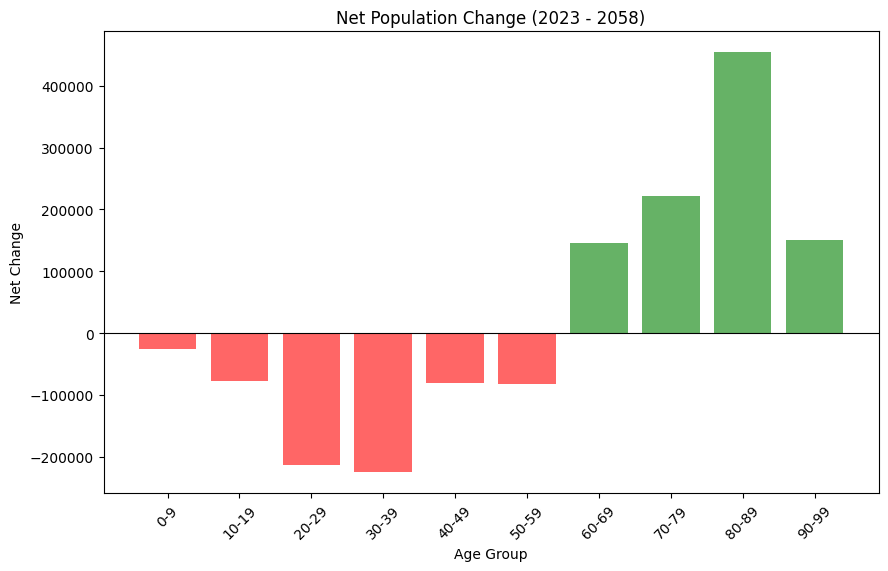

In [101]:
grouped_data['diff'] = grouped_data['pop_2058'] - grouped_data['pop_2023']
grouped_data['change_type'] = grouped_data['diff'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if x > 0 else 'red' for x in grouped_data['diff']]

ax.bar(labels, grouped_data['diff'], color=colors, alpha=0.6)
ax.axhline(0, color='black', linewidth=0.8) # Add a zero line

ax.set_ylabel('Net Change')
ax.set_xlabel('Age Group')
ax.set_title('Net Population Change (2023 - 2058)')
plt.xticks(rotation=45)
plt.show()


In [104]:
import numpy as np

bins = [0, 20, 67, np.inf]

# Define labels for the bins
labels = ['0-19', '20-64', '65+']

# Create the new column
pop['age_group'] = pd.cut(pop['alder'], bins=bins, labels=labels, right=False)

cols = [f"pop_{year}" for year in range(2023, 2058+1)]


pop_gruppert = pop.groupby("age_group")[cols].sum().reset_index()
pop_gruppert.columns = ["age_group"] + [f"{year}" for year in range(2023, 2058+1)]
pop_gruppert

,age_group,2023,2024,2025,2026,2027,2028,2029,2030,2031,...,2049,2050,2051,2052,2053,2054,2055,2056,2057,2058
0,0-19,1241427.0,1230841.0,1219136.0,1207351.0,1193429.0,1179219.0,1162789.0,1145299.0,1128356.0,...,1077654.0,1085457.0,1093067.0,1100434.0,1107715.0,1114707.0,1121296.0,1127734.0,1133635.0,1139173.0
1,20-64,3355714.0,3355759.0,3356475.0,3355200.0,3354717.0,3353673.0,3353738.0,3353418.0,3350786.0,...,3069616.0,3048432.0,3026874.0,3004381.0,2980138.0,2954336.0,2927547.0,2897747.0,2867265.0,2835659.0
2,65+,891843.0,912460.0,932888.0,954775.0,977313.0,1000017.0,1023179.0,1047344.0,1072615.0,...,1576326.0,1602358.0,1628047.0,1652495.0,1676159.0,1699198.0,1720845.0,1742937.0,1763531.0,1783006.0


(0.0, 2.0)

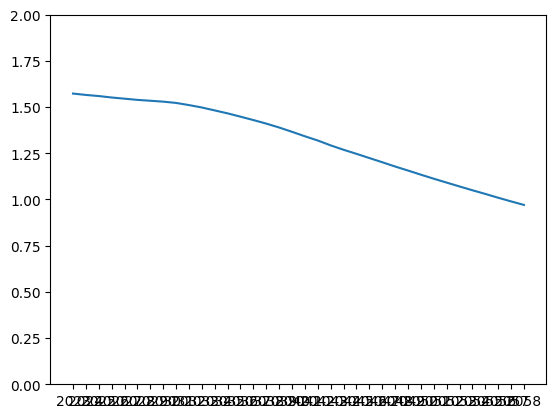

In [105]:
cols = [f"{year}" for year in range(2023, 2058+1)]
underholds_kvote = pop_gruppert[cols].iloc[1] / (pop_gruppert[cols].iloc[0] + pop_gruppert[cols].iloc[2])
plt.plot(underholds_kvote)
plt.ylim(0,2)

In [106]:
underholds_kvote

2023    1.573038
2024    1.565697
2025    1.559683
2026    1.551806
2027    1.545424
2028    1.538921
2029    1.534212
2030    1.529395
2031    1.522413
2032    1.510796
2033    1.497784
2034    1.481862
2035    1.466011
2036    1.448098
2037    1.429707
2038    1.410518
2039    1.389448
2040    1.366144
2041    1.341926
2042    1.319079
2043    1.292696
2044    1.268934
2045    1.247050
2046    1.224240
2047    1.201613
2048    1.178402
2049    1.156609
2050    1.134167
2051    1.112366
2052    1.091340
2053    1.070500
2054    1.049906
2055    1.030050
2056    1.009432
2057    0.989679
2058    0.970392
dtype: float64